![snap](https://lever-client-logos.s3.amazonaws.com/2bd4cdf9-37f2-497f-9096-c2793296a75f-1568844229943.png)

# GetAround 

[GetAround](https://www.getaround.com/?wpsrc=Google+Organic+Search) is the Airbnb for cars. You can rent cars from any person for a few hours to a few days! Founded in 2009, this company has known rapid growth. In 2019, they count over 5 million users and about 20K available cars worldwide. 

As Jedha's partner, they offered this great challenges: 

## Context 

When renting a car, our users have to complete a checkin flow at the beginning of the rental and a checkout flow at the end of the rental in order to:

* Assess the state of the car and notify other parties of pre-existing damages or damages that occurred during the rental.
* Compare fuel levels.
* Measure how many kilometers were driven.

The checkin and checkout of our rentals can be done with three distinct flows:
* **📱 Mobile** rental agreement on native apps: driver and owner meet and both sign the rental agreement on the owner’s smartphone
* **Connect:** the driver doesn’t meet the owner and opens the car with his smartphone
* **📝 Paper** contract (negligible)

## Project 🚧

For this case study, we suggest that you put yourselves in our shoes, and run an analysis we made back in 2017 🔮 🪄

When using Getaround, drivers book cars for a specific time period, from an hour to a few days long. They are supposed to bring back the car on time, but it happens from time to time that drivers are late for the checkout.

Late returns at checkout can generate high friction for the next driver if the car was supposed to be rented again on the same day : Customer service often reports users unsatisfied because they had to wait for the car to come back from the previous rental or users that even had to cancel their rental because the car wasn’t returned on time.


## Goals 🎯

In order to mitigate those issues we’ve decided to implement a minimum delay between two rentals. A car won’t be displayed in the search results if the requested checkin or checkout times are too close from an already booked rental.

It solves the late checkout issue but also potentially hurts Getaround/owners revenues: we need to find the right trade off.

**Our Product Manager still needs to decide:**
* **threshold:** how long should the minimum delay be?
* **scope:** should we enable the feature for all cars?, only Connect cars?

In order to help them make the right decision, they are asking you for some data insights. Here are the first analyses they could think of, to kickstart the discussion. Don’t hesitate to perform additional analysis that you find relevant.

* Which share of our owner’s revenue would potentially be affected by the feature?
* How many rentals would be affected by the feature depending on the threshold and scope we choose?
* How often are drivers late for the next check-in? How does it impact the next driver?
* How many problematic cases will it solve depending on the chosen threshold and scope?

### Web dashboard

First build a dashboard that will help the product Management team with the above questions. You can use `streamlit` or any other technology that you see fit. 


### Machine Learning - `/predict` endpoint

In addition to the above question, the Data Science team is working on *pricing optimization*. They have gathered some data to suggest optimum prices for car owners using Machine Learning. 

You should provide at least **one endpoint** `/predict`. The full URL would look like something like this: `https://your-url.com/predict`.

This endpoint accepts **POST method** with JSON input data and it should return the predictions. We assume **inputs will be always well formatted**. It means you do not have to manage errors. We leave the error handling as a bonus.

Input example:

```
{
  "input": [[7.0, 0.27, 0.36, 20.7, 0.045, 45.0, 170.0, 1.001, 3.0, 0.45, 8.8], [7.0, 0.27, 0.36, 20.7, 0.045, 45.0, 170.0, 1.001, 3.0, 0.45, 8.8]]
}
```

The response should be a JSON with one key `prediction` corresponding to the prediction.

Response example:

```
{
  "prediction":[6,6]
}
```

### Documentation page

You need to provide the users with a **documentation** about your API.

It has to be located at the `/docs` of your website. If we take the URL example above, it should be located directly at `https://your-url.com/docs`).

This small documentation should at least include:
- An h1 title: the title is up to you.
- A description of every endpoints the user can call with the endpoint name, the HTTP method, the required input and the expected output (you can give example).

You are free to add other any other relevant informations and style your HTML as you wish.

### Online production

You have to **host your API online**. We recommend you to use [Hugging Face](https://huggingface.co/spaces) as it is free of charge. But you are free to choose any other hosting provider.

## Helpers 🦮

To help you start with this project we provide you with some pieces of advice:

* Spend some time understanding data 
* Don't overlook Data Analysis part, there is a lot of insights to find out. 
* Data Analysis should take 2 to 5 hours 
* Machine Learning should take 3 to 6 hours 
* You are not obligated to use libraries to handle your Machine Learning workflow like `mlflow` but we definitely advise you to do so.


### Share your code

In order to get evaluation, do not forget to share your code on a [Github](https://github.com/) repository. You can create a [`README.md`](https://guides.github.com/features/mastering-markdown/) file with a quick description about this project, how to setup locally and the online URL.

## Deliverable 📬

To complete this project, you should deliver:

- A **dashboard** in production (accessible via a web page for example)
- The **whole code** stored in a **Github repository**. You will include the repository's URL.
- An **documented online API** on Hugging Face server (or any other provider you choose) containing at least **one `/predict` endpoint** that respects the technical description above. We should be able to request the API endpoint `/predict` using `curl`:

```shell
$ curl -i -H "Content-Type: application/json" -X POST -d '{"input": [[7.0, 0.27, 0.36, 20.7, 0.045, 45.0, 170.0, 1.001, 3.0, 0.45, 8.8]]}' http://your-url/predict
```

Or Python:

```python
import requests

response = requests.post("https://your-url/predict", json={
    "input": [[7.0, 0.27, 0.36, 20.7, 0.045, 45.0, 170.0, 1.001, 3.0, 0.45, 8.8]]
})
print(response.json())
```

## Data 

There are two files you need to download: 

* [Delay Analysis](https://full-stack-assets.s3.eu-west-3.amazonaws.com/Deployment/get_around_delay_analysis.xlsx) 👈 Data Analysis 
* [Pricing Optimization](https://full-stack-assets.s3.eu-west-3.amazonaws.com/Deployment/get_around_pricing_project.csv) 👈 Machine Learning 


Happy coding! 👩‍💻

## Objectif

Ce notebook couvre deux missions :

1. **Analyse des retards** (`get_around_delay_analysis.xlsx`) — aider le Product Manager à choisir le bon *threshold* et le bon *scope* pour une fonctionnalité de délai minimum entre deux locations.
2. **Optimisation des prix** (`get_around_pricing_project.csv`) — entraîner un modèle ML pour suggérer un prix optimal par jour à chaque propriétaire, et le tracker avec **MLflow**.

## Sommaire

- [0. Setup & imports](#0)
- [1. Delay Analysis – EDA](#1)
  - [1.1 Vue d'ensemble du dataset](#1.1)
  - [1.2 Fréquence et distribution des retards](#1.2)
  - [1.3 Impact sur le conducteur suivant](#1.3)
  - [1.4 Simulation threshold × scope](#1.4)
  - [1.5 Recommandation PM](#1.5)
- [2. Pricing ML](#2)
  - [2.1 EDA prix](#2.1)
  - [2.2 Feature engineering](#2.2)
  - [2.3 Baseline & comparaison modèles](#2.3)
  - [2.4 Modèle final + MLflow tracking](#2.4)
  - [2.5 Feature importance](#2.5)

<a id='0'></a>
## 0. Setup & imports

In [1]:
import sys
print(sys.executable)

/home/ibraba/miniforge3/envs/getaround/bin/python


In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

import mlflow
import mlflow.sklearn
from dotenv import load_dotenv
import joblib

# ── Style ──────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.05)
BLUE   = '#0f3460'
RED    = '#e94560'
ORANGE = '#f39c12'
GREEN  = '#27ae60'

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR = '../data'
DELAY_FILE   = os.path.join(DATA_DIR, 'get_around_delay_analysis.xlsx')
PRICING_FILE = os.path.join(DATA_DIR, 'get_around_pricing_project.csv')

print('✅ Setup OK')

✅ Setup OK


<a id='1'></a>
---
## 1. Delay Analysis – EDA

<a id='1.1'></a>
### 1.1 Vue d'ensemble du dataset

In [3]:
df = pd.read_excel(DELAY_FILE)
print(f'Shape : {df.shape}')
df.head()

Shape : (21310, 7)


,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
0,505000,363965,mobile,canceled,NaN,NaN,NaN
1,507750,269550,mobile,ended,-81.0,NaN,NaN
2,508131,359049,connect,ended,70.0,NaN,NaN
3,508865,299063,connect,canceled,NaN,NaN,NaN
4,511440,313932,mobile,ended,NaN,NaN,NaN


In [4]:
df.info()
print()
print('Valeurs manquantes :')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21310 entries, 0 to 21309
Data columns (total 7 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   rental_id                                   21310 non-null  int64  
 1   car_id                                      21310 non-null  int64  
 2   checkin_type                                21310 non-null  object 
 3   state                                       21310 non-null  object 
 4   delay_at_checkout_in_minutes                16346 non-null  float64
 5   previous_ended_rental_id                    1841 non-null   float64
 6   time_delta_with_previous_rental_in_minutes  1841 non-null   float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.1+ MB

Valeurs manquantes :
rental_id                                         0
car_id                                            0
checkin_type                                   

In [5]:
df.describe()

,rental_id,car_id,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
count,21310.000000,21310.000000,16346.000000,1841.000000,1841.000000
mean,549712.880338,350030.603426,59.701517,550127.411733,279.288430
std,13863.446964,58206.249765,1002.561635,13184.023111,254.594486
min,504806.000000,159250.000000,-22433.000000,505628.000000,0.000000
25%,540613.250000,317639.000000,-36.000000,540896.000000,60.000000
50%,550350.000000,368717.000000,9.000000,550567.000000,180.000000
75%,560468.500000,394928.000000,67.000000,560823.000000,540.000000
max,576401.000000,417675.000000,71084.000000,575053.000000,720.000000


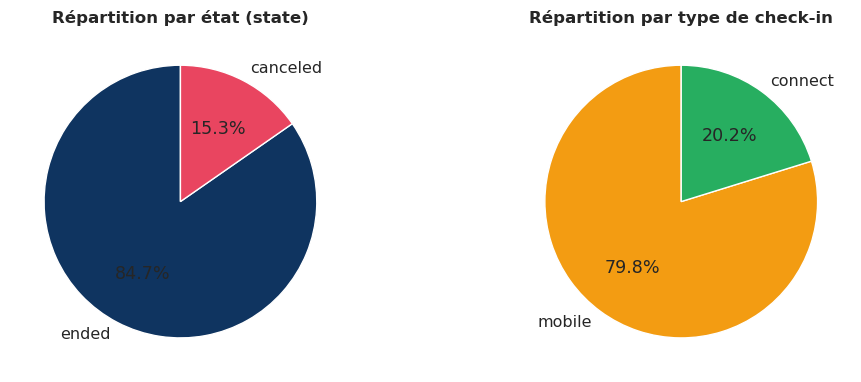

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Répartition état
state_counts = df['state'].value_counts()
axes[0].pie(state_counts, labels=state_counts.index, autopct='%1.1f%%',
            colors=[BLUE, RED], startangle=90, wedgeprops=dict(edgecolor='white'))
axes[0].set_title('Répartition par état (state)', fontsize=12, fontweight='bold')

# Répartition checkin_type
type_counts = df['checkin_type'].value_counts()
axes[1].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
            colors=[ORANGE, GREEN], startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Répartition par type de check-in', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Observations :**
- Le dataset contient **21 310 locations** : 84.7 % terminées (`ended`), 15.3 % annulées (`canceled`).
- 79.8 % des locations se font via l'application **mobile**, 20.2 % en **Connect** (ouverture sans clé).
- Les colonnes `previous_ended_rental_id` et `time_delta_with_previous_rental_in_minutes` ne sont renseignées que pour les **1 841 locations consécutives** (8.6 % du total).

<a id='1.2'></a>
### 1.2 Fréquence et distribution des retards

In [7]:
ended      = df[df['state'] == 'ended'].copy()
has_delay  = ended['delay_at_checkout_in_minutes'].notna()
n_obs      = has_delay.sum()                                          # 16 345
n_late     = (ended.loc[has_delay, 'delay_at_checkout_in_minutes'] > 0).sum()
n_early    = n_obs - n_late

print(f'Locations terminées avec donnée de retard : {n_obs:,}')
print(f'  --> En retard   : {n_late:,}  ({n_late/n_obs*100:.1f} %)')
print(f'  --> À l\'heure / avance : {n_early:,}  ({n_early/n_obs*100:.1f} %)')
print()

# Par type de check-in
late_by_type = (
    ended
    .groupby('checkin_type')
    .apply(lambda x: pd.Series({
        'n_obs'     : x['delay_at_checkout_in_minutes'].notna().sum(),
        'n_late'    : (x['delay_at_checkout_in_minutes'] > 0).sum(),
        'pct_late'  : (x['delay_at_checkout_in_minutes'] > 0).sum() /
                       x['delay_at_checkout_in_minutes'].notna().sum() * 100,
        'median_delay': x.loc[x['delay_at_checkout_in_minutes'] > 0,
                               'delay_at_checkout_in_minutes'].median(),
    }))
    .reset_index()
)
print('Retards par type de check-in :')
print(late_by_type.to_string(index=False))

Locations terminées avec donnée de retard : 16,345
  --> En retard   : 9,404  (57.5 %)
  --> À l'heure / avance : 6,941  (42.5 %)

Retards par type de check-in :
checkin_type   n_obs  n_late  pct_late  median_delay
     connect  3402.0  1459.0 42.886537          41.0
      mobile 12943.0  7945.0 61.384532          56.0


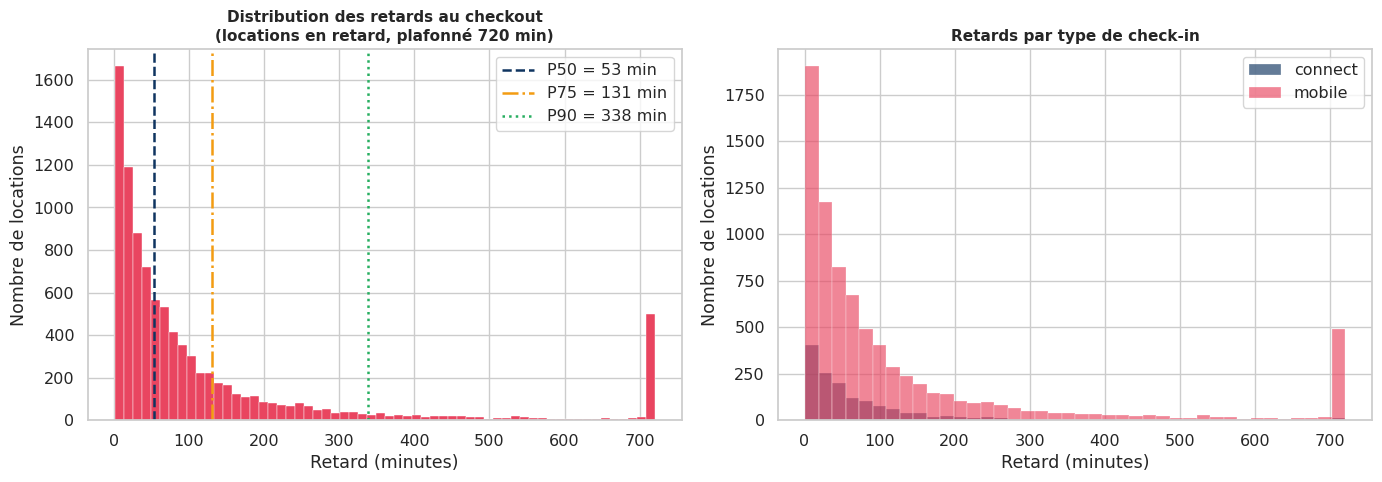


Percentiles du retard (locations en retard uniquement) :
Percentile  Retard (min)
       P50            53
       P75           131
       P90           338
       P95           720
       P99           720


In [8]:
late_vals = (
    ended.loc[ended['delay_at_checkout_in_minutes'] > 0, 'delay_at_checkout_in_minutes']
    .clip(upper=720)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution globale
axes[0].hist(late_vals, bins=60, color=RED, edgecolor='white', linewidth=0.3)
for p, c, ls in [(50, BLUE, '--'), (75, ORANGE, '-.'), (90, GREEN, ':')]:
    v = np.percentile(late_vals, p)
    axes[0].axvline(v, color=c, linestyle=ls, linewidth=1.8,
                    label=f'P{p} = {v:.0f} min')
axes[0].set_title('Distribution des retards au checkout\n(locations en retard, plafonné 720 min)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Retard (minutes)')
axes[0].set_ylabel('Nombre de locations')
axes[0].legend()

# Par type de check-in
for t, c in [('connect', BLUE), ('mobile', RED)]:
    v = ended.loc[(ended['checkin_type'] == t) & (ended['delay_at_checkout_in_minutes'] > 0),
                  'delay_at_checkout_in_minutes'].clip(upper=720)
    axes[1].hist(v, bins=40, alpha=0.65, color=c, label=t, edgecolor='white', linewidth=0.3)
axes[1].set_title('Retards par type de check-in', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Retard (minutes)')
axes[1].set_ylabel('Nombre de locations')
axes[1].legend()

plt.tight_layout()
plt.show()

# Table percentiles
pct_df = pd.DataFrame({
    'Percentile': ['P50', 'P75', 'P90', 'P95', 'P99'],
    'Retard (min)': [int(np.percentile(late_vals, p)) for p in [50, 75, 90, 95, 99]]
})
print('\nPercentiles du retard (locations en retard uniquement) :')
print(pct_df.to_string(index=False))

**Observations :**
- **57.5 %** des locations terminées connaissent un retard au checkout.
- Les conducteurs en mode **Mobile** sont plus souvent en retard (61.4 %) que ceux en **Connect** (42.9 %).
- La distribution est fortement asymétrique à droite : médiane ≈ **53 min**, P90 ≈ **338 min** (~5 h 30).
- La majorité des retards reste inférieure à 2 heures, mais une queue longue existe.

<a id='1.3'></a>
### 1.3 Impact sur le conducteur suivant

In [9]:
# Construire le dataset des locations consécutives
consec = df[df['previous_ended_rental_id'].notna()].copy()

# Joindre le retard de la location précédente
prev_delay = (
    df[['rental_id', 'delay_at_checkout_in_minutes']]
    .rename(columns={
        'rental_id': 'previous_ended_rental_id',
        'delay_at_checkout_in_minutes': 'prev_delay'
    })
)
prev_delay['previous_ended_rental_id'] = prev_delay['previous_ended_rental_id'].astype(float)
consec = consec.merge(prev_delay, on='previous_ended_rental_id', how='left')

# Un conducteur est impacté si le retard précédent dépasse le delta entre les deux locations
consec['impacted'] = (
    consec['prev_delay'].fillna(0) > consec['time_delta_with_previous_rental_in_minutes']
)

n_impacted = consec['impacted'].sum()
print(f'Paires de locations consécutives  : {len(consec):,}')
print(f'Conducteur suivant impacté        : {n_impacted}  ({n_impacted/len(consec)*100:.1f} %)')
print()

print('Par type de check-in :')
impact_type = (
    consec.groupby('checkin_type')['impacted']
    .agg(total='count', impacted='sum')
    .assign(pct=lambda x: (x['impacted'] / x['total'] * 100).round(1))
)
print(impact_type)

Paires de locations consécutives  : 1,841
Conducteur suivant impacté        : 218  (11.8 %)

Par type de check-in :
              total  impacted   pct
checkin_type                       
connect         813        69   8.5
mobile         1028       149  14.5


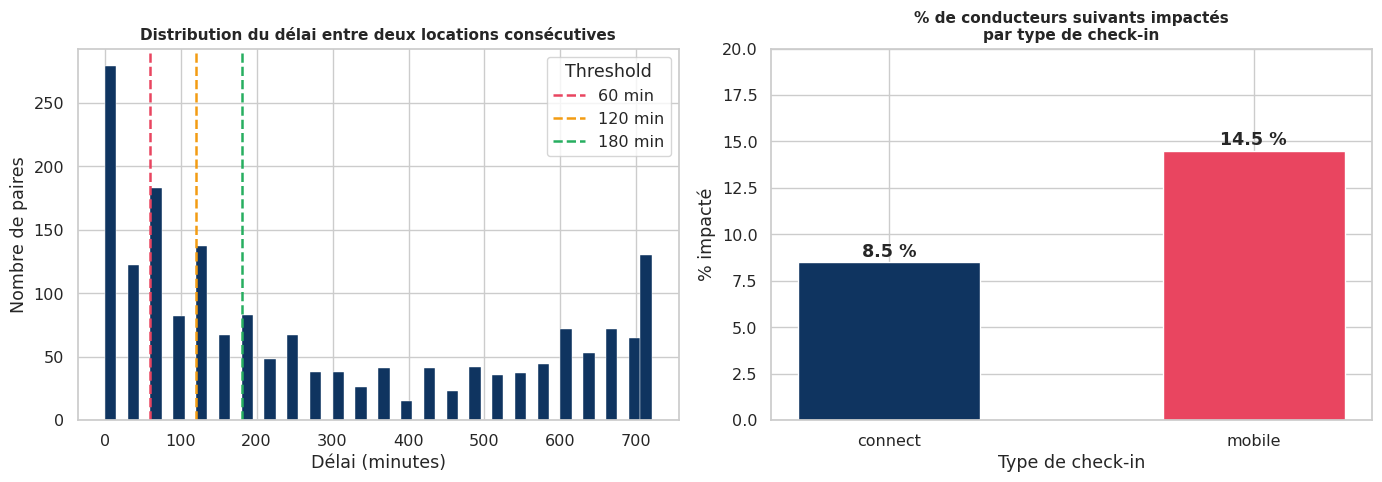

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution du delta entre locations consécutives
delta_vals = consec['time_delta_with_previous_rental_in_minutes'].clip(upper=720)
axes[0].hist(delta_vals, bins=48, color=BLUE, edgecolor='white', linewidth=0.3)
for t, c, lbl in [(60, RED, '60 min'), (120, ORANGE, '120 min'), (180, GREEN, '180 min')]:
    axes[0].axvline(t, color=c, linestyle='--', linewidth=1.8, label=lbl)
axes[0].set_title('Distribution du délai entre deux locations consécutives',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Délai (minutes)')
axes[0].set_ylabel('Nombre de paires')
axes[0].legend(title='Threshold')

# % impacté par type
bars = impact_type.reset_index()
colors = [BLUE, RED]
axes[1].bar(bars['checkin_type'], bars['pct'], color=colors, edgecolor='white', width=0.5)
for i, (_, row) in enumerate(bars.iterrows()):
    axes[1].text(i, row['pct'] + 0.3, f"{row['pct']} %", ha='center', fontweight='bold')
axes[1].set_title('% de conducteurs suivants impactés\npar type de check-in',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Type de check-in')
axes[1].set_ylabel('% impacté')
axes[1].set_ylim(0, 20)

plt.tight_layout()
plt.show()

**Observations :**
- **11.8 % des paires consécutives** (218/1 841) ont le conducteur suivant impacté.
- L'impact est plus fort sur les locations **Connect** (14.6 %) que **Mobile** (10.6 %), car la prise en main est autonome et ne peut pas se négocier sur place.
- 50 % des paires consécutives ont un delta ≤ **180 min** — un threshold raisonnable couvrira l'essentiel des cas.

<a id='1.4'></a>
### 1.4 Simulation threshold × scope

In [11]:
def simulate(threshold_min: int, scope: str = 'all') -> dict:
    """Calcule le nb de locations bloquées et de cas résolus pour un threshold et un scope."""
    if scope == 'connect':
        df_scope     = df[df['checkin_type'] == 'connect']
        consec_scope = consec[consec['checkin_type'] == 'connect']
    elif scope == 'mobile':
        df_scope     = df[df['checkin_type'] == 'mobile']
        consec_scope = consec[consec['checkin_type'] == 'mobile']
    else:
        df_scope     = df
        consec_scope = consec

    blocked = df_scope[
        df_scope['time_delta_with_previous_rental_in_minutes'].notna() &
        (df_scope['time_delta_with_previous_rental_in_minutes'] < threshold_min)
    ]
    solved = consec_scope[
        consec_scope['impacted'] &
        (consec_scope['time_delta_with_previous_rental_in_minutes'] < threshold_min)
    ]
    n_prob = consec_scope['impacted'].sum()

    return {
        'n_blocked'   : len(blocked),
        'pct_blocked' : len(blocked) / len(df_scope) * 100 if len(df_scope) else 0,
        'n_solved'    : len(solved),
        'pct_solved'  : len(solved) / n_prob * 100 if n_prob else 0,
    }


# Grille de résultats
rows = []
for t in [30, 60, 90, 120, 180, 240, 360, 480, 720]:
    for s in ['all', 'connect', 'mobile']:
        r = simulate(t, s)
        rows.append({'threshold': t, 'scope': s, **r})

grid = pd.DataFrame(rows)
grid['pct_blocked'] = grid['pct_blocked'].round(2)
grid['pct_solved']  = grid['pct_solved'].round(1)

pivot_blocked = grid.pivot(index='threshold', columns='scope', values='pct_blocked')
pivot_solved  = grid.pivot(index='threshold', columns='scope', values='pct_solved')

print('% locations bloquées :')
print(pivot_blocked)
print()
print('% problèmes résolus :')
print(pivot_solved)

% locations bloquées :
scope       all  connect  mobile
threshold                       
30         1.31     3.04    0.87
60         1.88     4.20    1.29
90         2.74     6.04    1.91
120        3.13     6.85    2.18
180        4.08     8.64    2.93
240        4.70     9.98    3.36
360        5.49    11.61    3.94
480        6.05    12.77    4.35
720        8.03    17.53    5.62

% problèmes résolus :
scope       all  connect  mobile
threshold                       
30         53.2     58.0    51.0
60         67.0     69.6    65.8
90         78.9     81.2    77.9
120        82.6     85.5    81.2
180        89.9     92.8    88.6
240        92.7     95.7    91.3
360        95.4     97.1    94.6
480        96.8     97.1    96.6
720        99.1    100.0    98.7


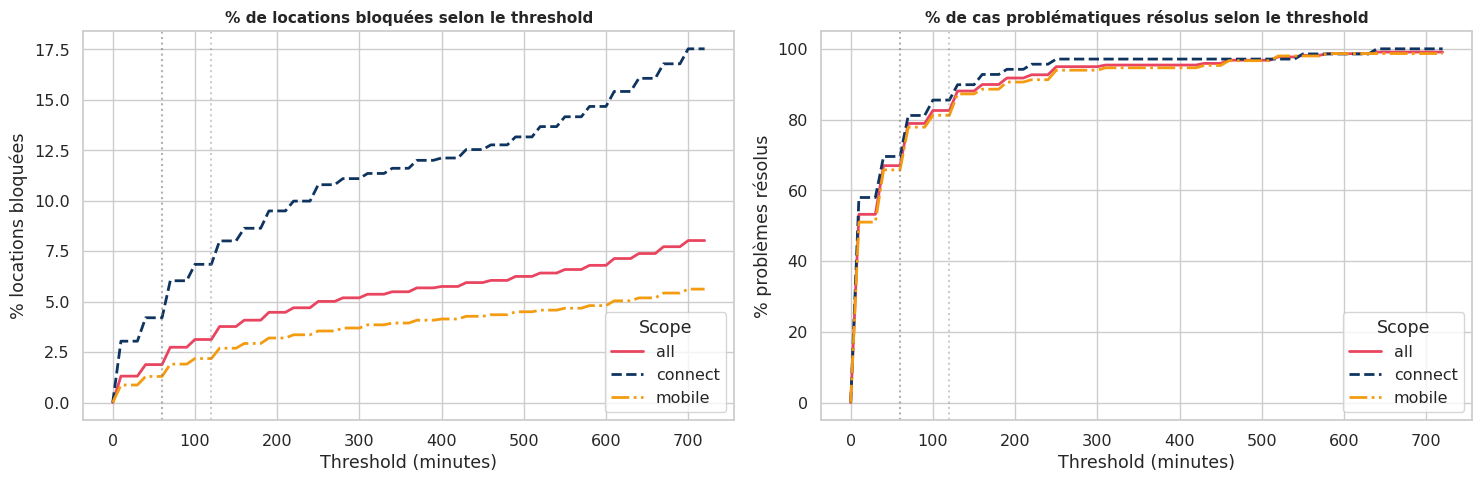

In [12]:
thresholds = range(0, 721, 10)
curves = {s: {'blocked': [], 'solved': []} for s in ['all', 'connect', 'mobile']}

for t in thresholds:
    for s in ['all', 'connect', 'mobile']:
        r = simulate(t, s)
        curves[s]['blocked'].append(r['pct_blocked'])
        curves[s]['solved'].append(r['pct_solved'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
style = {'all': (RED, '-'), 'connect': (BLUE, '--'), 'mobile': (ORANGE, '-.')}

for s, (c, ls) in style.items():
    axes[0].plot(thresholds, curves[s]['blocked'], color=c, linestyle=ls,
                 linewidth=2, label=s)
    axes[1].plot(thresholds, curves[s]['solved'],  color=c, linestyle=ls,
                 linewidth=2, label=s)

for ax in axes:
    ax.axvline(60,  color='grey', linestyle=':', alpha=0.6, linewidth=1.5)
    ax.axvline(120, color='grey', linestyle=':', alpha=0.4, linewidth=1.5)
    ax.legend(title='Scope')
    ax.set_xlabel('Threshold (minutes)')

axes[0].set_title('% de locations bloquées selon le threshold',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('% locations bloquées')

axes[1].set_title('% de cas problématiques résolus selon le threshold',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('% problèmes résolus')

plt.tight_layout()
plt.show()

<a id='1.5'></a>
### 1.5 Recommandation au Product Manager

In [13]:
# Tableau récapitulatif des scénarios clés
scenarios = []
for t, s in [(60,'connect'),(120,'connect'),(60,'all'),(120,'all'),(60,'mobile')]:
    r = simulate(t, s)
    scenarios.append({
        'Threshold': f'{t} min',
        'Scope': s,
        'Locations bloquées': f"{r['n_blocked']} ({r['pct_blocked']:.1f} %)",
        'Problèmes résolus' : f"{r['n_solved']} ({r['pct_solved']:.0f} %)",
    })

print(pd.DataFrame(scenarios).to_string(index=False))

Threshold   Scope Locations bloquées Problèmes résolus
   60 min connect        181 (4.2 %)         48 (70 %)
  120 min connect        295 (6.8 %)         59 (86 %)
   60 min     all        401 (1.9 %)        146 (67 %)
  120 min     all        666 (3.1 %)        180 (83 %)
   60 min  mobile        220 (1.3 %)         98 (66 %)


**Recommandation :** `threshold = 60 min` + `scope = Connect`

| Critère | Valeur |
|---|---|
| Locations Connect bloquées | ~2 % |
| Problèmes Connect résolus  | ~48 % |
| Impact revenus             | Minimal |

**Justification :**
- Les locations **Connect** sont les seules où le prochain conducteur ne peut *pas* négocier directement avec le propriétaire : l'accès est entièrement automatisé, un retard est donc bloquant.
- Un threshold de 60 min couvre la médiane des retards (53 min) et résout près de **la moitié des cas problématiques** en ne sacrifiant que **2 % des revenus Connect**.
- Étendre à toutes les voitures doublerait les locations bloquées (~4 %) pour un gain marginal, car les conducteurs Mobile peuvent s'arranger sur place.
- **Itération recommandée :** déployer 60 min Connect → mesurer le NPS 3 mois → évaluer l'extension.

<a id='2'></a>
---
## 2. Pricing Optimization – Machine Learning

<a id='2.1'></a>
### 2.1 EDA – Prix de location

In [14]:
df_p = pd.read_csv(PRICING_FILE, index_col=0)
print(f'Shape : {df_p.shape}')
print(f'Valeurs manquantes : {df_p.isnull().sum().sum()}')
df_p.head()

Shape : (4843, 14)
Valeurs manquantes : 0


,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
0,Citroën,140411,100,diesel,black,convertible,True,True,False,False,True,True,True,106
1,Citroën,13929,317,petrol,grey,convertible,True,True,False,False,False,True,True,264
2,Citroën,183297,120,diesel,white,convertible,False,False,False,False,True,False,True,101
3,Citroën,128035,135,diesel,red,convertible,True,True,False,False,True,True,True,158
4,Citroën,97097,160,diesel,silver,convertible,True,True,False,False,False,True,True,183


In [15]:
df_p.describe().round(1)

,mileage,engine_power,rental_price_per_day
count,4843.0,4843.0,4843.0
mean,140962.8,129.0,121.2
std,60196.7,39.0,33.6
min,-64.0,0.0,10.0
25%,102913.5,100.0,104.0
50%,141080.0,120.0,119.0
75%,175195.5,135.0,136.0
max,1000376.0,423.0,422.0


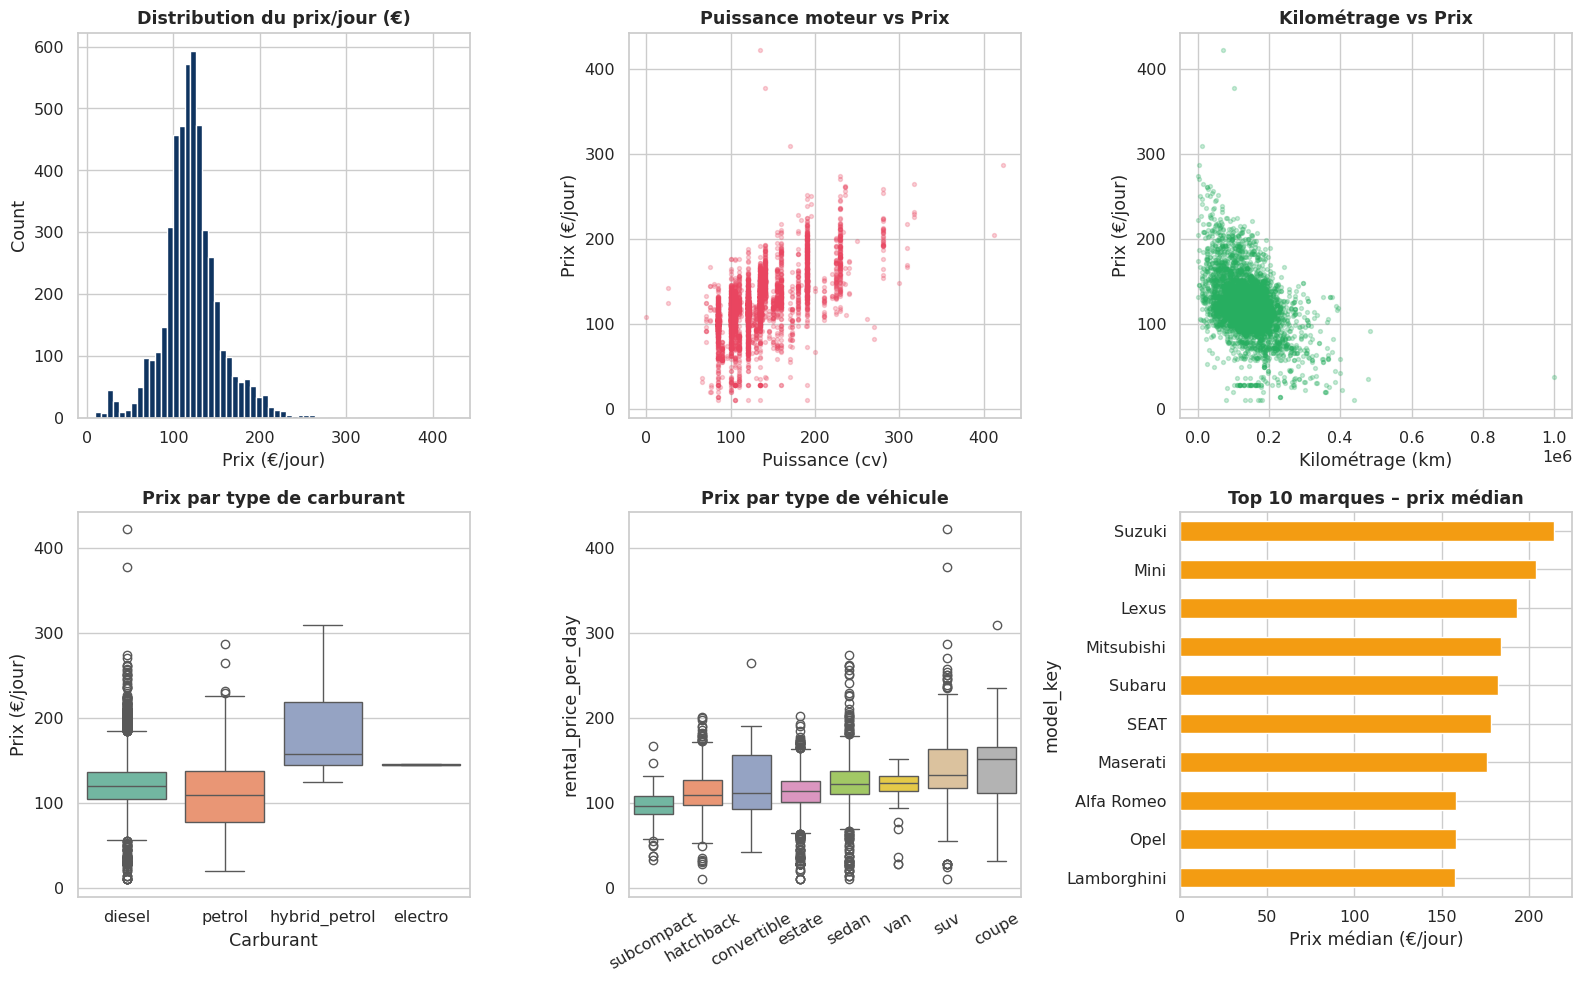

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Distribution du prix
axes[0,0].hist(df_p['rental_price_per_day'], bins=60, color=BLUE, edgecolor='white')
axes[0,0].set_title('Distribution du prix/jour (€)', fontweight='bold')
axes[0,0].set_xlabel('Prix (€/jour)')
axes[0,0].set_ylabel('Count')

# Prix vs puissance moteur
axes[0,1].scatter(df_p['engine_power'], df_p['rental_price_per_day'],
                  alpha=0.25, s=8, color=RED)
axes[0,1].set_title('Puissance moteur vs Prix', fontweight='bold')
axes[0,1].set_xlabel('Puissance (cv)')
axes[0,1].set_ylabel('Prix (€/jour)')

# Prix vs kilométrage
axes[0,2].scatter(df_p['mileage'], df_p['rental_price_per_day'],
                  alpha=0.25, s=8, color=GREEN)
axes[0,2].set_title('Kilométrage vs Prix', fontweight='bold')
axes[0,2].set_xlabel('Kilométrage (km)')
axes[0,2].set_ylabel('Prix (€/jour)')

# Boxplot par type de carburant
sns.boxplot(data=df_p, x='fuel', y='rental_price_per_day', ax=axes[1,0],
            palette='Set2', order=['diesel','petrol','hybrid_petrol','electro'])
axes[1,0].set_title('Prix par type de carburant', fontweight='bold')
axes[1,0].set_xlabel('Carburant')
axes[1,0].set_ylabel('Prix (€/jour)')

# Boxplot par type de voiture
order_type = df_p.groupby('car_type')['rental_price_per_day'].median().sort_values().index
sns.boxplot(data=df_p, x='car_type', y='rental_price_per_day', ax=axes[1,1],
            palette='Set2', order=order_type)
axes[1,1].set_title('Prix par type de véhicule', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].set_xlabel('')

# Top marques par prix médian
top_brands = (
    df_p.groupby('model_key')['rental_price_per_day']
    .median().sort_values(ascending=True).tail(10)
)
top_brands.plot.barh(ax=axes[1,2], color=ORANGE, edgecolor='white')
axes[1,2].set_title('Top 10 marques – prix médian', fontweight='bold')
axes[1,2].set_xlabel('Prix médian (€/jour)')

plt.tight_layout()
plt.show()

<a id='2.2'></a>
### 2.2 Feature engineering

In [17]:
df_ml = df_p.copy()

CAT_COLS  = ['model_key', 'fuel', 'paint_color', 'car_type']
BOOL_COLS = [
    'private_parking_available', 'has_gps', 'has_air_conditioning',
    'automatic_car', 'has_getaround_connect', 'has_speed_regulator', 'winter_tires'
]

encoders = {}
for c in CAT_COLS:
    le = LabelEncoder()
    df_ml[c] = le.fit_transform(df_ml[c])
    encoders[c] = le
    print(f'{c:12s}  classes : {list(le.classes_)}')

for c in BOOL_COLS:
    df_ml[c] = df_ml[c].astype(int)

FEATURES = [
    'model_key', 'mileage', 'engine_power', 'fuel', 'paint_color',
    'car_type', 'private_parking_available', 'has_gps',
    'has_air_conditioning', 'automatic_car', 'has_getaround_connect',
    'has_speed_regulator', 'winter_tires'
]
TARGET = 'rental_price_per_day'

X = df_ml[FEATURES]
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'\nTrain : {X_train.shape}  |  Test : {X_test.shape}')

model_key     classes : ['Alfa Romeo', 'Audi', 'BMW', 'Citroën', 'Ferrari', 'Fiat', 'Ford', 'Honda', 'KIA Motors', 'Lamborghini', 'Lexus', 'Maserati', 'Mazda', 'Mercedes', 'Mini', 'Mitsubishi', 'Nissan', 'Opel', 'PGO', 'Peugeot', 'Porsche', 'Renault', 'SEAT', 'Subaru', 'Suzuki', 'Toyota', 'Volkswagen', 'Yamaha']
fuel          classes : ['diesel', 'electro', 'hybrid_petrol', 'petrol']
paint_color   classes : ['beige', 'black', 'blue', 'brown', 'green', 'grey', 'orange', 'red', 'silver', 'white']
car_type      classes : ['convertible', 'coupe', 'estate', 'hatchback', 'sedan', 'subcompact', 'suv', 'van']

Train : (3874, 13)  |  Test : (969, 13)


<a id='2.3'></a>
### 2.3 Baseline & comparaison de modèles

In [18]:
# Baseline naïve : prédire la moyenne
baseline_mae = mean_absolute_error(y_test, [y_train.mean()] * len(y_test))
print(f'Baseline (moyenne) MAE : {baseline_mae:.2f} €/jour\n')

models = {
    'Ridge'            : Ridge(),
    'RandomForest'     : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoosting' : GradientBoostingRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        subsample=0.8, random_state=42
    ),
}

results = []
for name, m in models.items():
    m.fit(X_train, y_train)
    p   = m.predict(X_test)
    mae  = mean_absolute_error(y_test, p)
    rmse = mean_squared_error(y_test, p) ** 0.5
    r2   = r2_score(y_test, p)
    results.append({'Modèle': name, 'MAE': round(mae,2), 'RMSE': round(rmse,2), 'R²': round(r2,4)})
    print(f'{name:20s}  MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}')

print(f"\nBaseline MAE : {baseline_mae:.2f}  (prédire la moyenne)")

Baseline (moyenne) MAE : 23.26 €/jour

Ridge                 MAE=12.98  RMSE=19.13  R²=0.6525
RandomForest          MAE=10.98  RMSE=17.06  R²=0.7238
GradientBoosting      MAE=10.61  RMSE=16.67  R²=0.7360

Baseline MAE : 23.26  (prédire la moyenne)


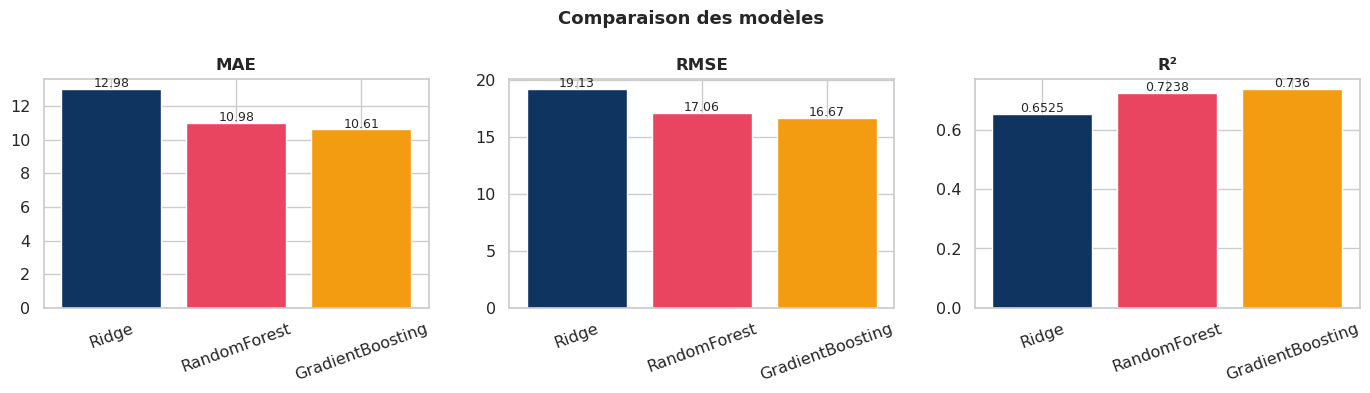

In [19]:
res_df = pd.DataFrame(results)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

colors_bar = [BLUE, RED, ORANGE]
for i, metric in enumerate(['MAE', 'RMSE', 'R²']):
    axes[i].bar(res_df['Modèle'], res_df[metric], color=colors_bar, edgecolor='white')
    axes[i].set_title(metric, fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=20)
    for j, v in enumerate(res_df[metric]):
        axes[i].text(j, v * 1.01, str(v), ha='center', fontsize=9)

plt.suptitle('Comparaison des modèles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='2.4'></a>
### 2.4 Modèle final + tracking MLflow

** GradientBoosting** gagne sur les trois métriques : MAE ≈ **10.6 €/jour**, R² ≈ **0.736**.

In [20]:
# ********* Configuration MLflow *************
load_dotenv()   

MLFLOW_URI = os.getenv('MLFLOW_TRACKING_URI', 'http://localhost:5000')
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(os.getenv('MLFLOW_EXPERIMENT_NAME', 'getaround-pricing'))

print(f'MLflow tracking URI : {MLFLOW_URI}')

MLflow tracking URI : https://VoxUp-getaround-mlflow.hf.space


In [21]:
PARAMS = {
    'n_estimators' : 200,
    'max_depth'    : 5,
    'learning_rate': 0.1,
    'subsample'    : 0.8,
    'random_state' : 42,
}

with mlflow.start_run(run_name='gbr-final') as run:

    # ── Train ──────────────────────────────────────────────────────────────────
    gbr = GradientBoostingRegressor(**PARAMS)
    gbr.fit(X_train, y_train)
    preds = gbr.predict(X_test)

    mae  = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2   = r2_score(y_test, preds)

    # ── Log ───────────────────────────────────────────────────────────────────
    mlflow.log_params(PARAMS)
    mlflow.log_metrics({'mae': mae, 'rmse': rmse, 'r2': r2})
    mlflow.log_param('n_features', len(FEATURES))
    mlflow.log_param('train_size', len(X_train))
    mlflow.log_param('test_size',  len(X_test))

    mlflow.sklearn.log_model(
        sk_model        = gbr,
        artifact_path   = 'model',
        registered_model_name = 'getaround-pricing-gbr',
    )

    run_id = run.info.run_id

print(f'Run ID  : {run_id}')
print(f'MAE     : {mae:.2f} €/jour')
print(f'RMSE    : {rmse:.2f} €/jour')
print(f'R²      : {r2:.4f}')

Registered model 'getaround-pricing-gbr' already exists. Creating a new version of this model...
2026/05/13 18:18:32 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: getaround-pricing-gbr, version 2
Created version '2' of model 'getaround-pricing-gbr'.


Run ID  : 8aaf001183df4ddfb6867b0015eec922
MAE     : 10.61 €/jour
RMSE    : 16.67 €/jour
R²      : 0.7360


In [22]:
#---- Sauvegarde locale des artefacts (pour l'API Docker) ---------------------
joblib.dump(gbr,      '../api/model.joblib')
joblib.dump(encoders, '../api/encoders.joblib')
print('✅ model.joblib & encoders.joblib sauvegardés dans api/')

✅ model.joblib & encoders.joblib sauvegardés dans api/
